First probe positions: [ 10  40  70 100 130 160 190 220 250 280]
Intensity of first signal shape: (5, 2000)


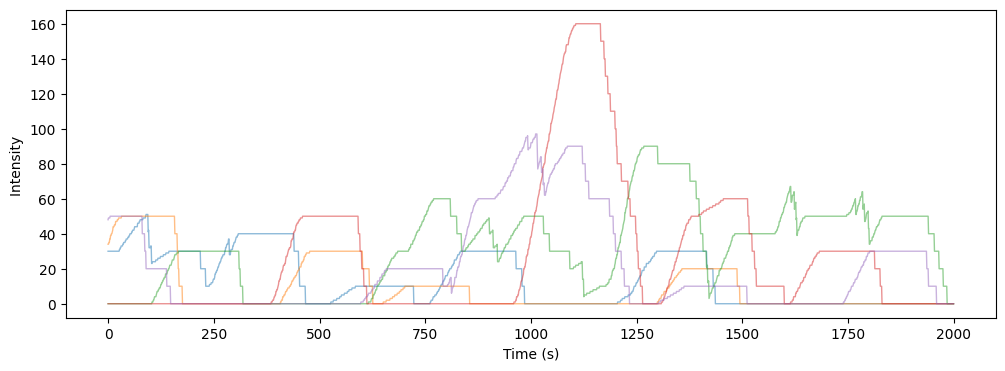

In [ ]:
import numpy as np
from numba import njit, types
from numba.typed import List as TypedList
from joblib import Parallel, delayed
from matplotlib import gridspec
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image as IPImage, display


def plot_spot(amplitude, sigma=2, grid_size=13):
    mu_x, mu_y = (grid_size/2)-0.5, (grid_size/2)-0.5
    x = np.linspace(0, grid_size - 1, grid_size)
    y = np.linspace(0, grid_size - 1, grid_size)
    x, y = np.meshgrid(x, y)
    z = amplitude * np.exp(-((x - mu_x)**2 + (y - mu_y)**2) / (2 * sigma**2))
    # Normalize and return as uint8
    if z.max() > 0:
        z = (255*(z/z.max())).astype(np.uint8)
    else:
        z = z.astype(np.uint8)
    return z



def plot_RibosomeMovement_and_Microscope(RibosomePositions, IntensityVector, probePositions, SecondIntensityVector=None, second_probePositions=None, fileNameGif='temp_gif', color='red', second_color='lime', FrameVelocity=10, timePerturbationApplication=None):
    time = np.arange(0, len(IntensityVector),1)
    geneLength = np.max(RibosomePositions)
    
    # Normalize IntensityVector
    IntensityVector = IntensityVector / np.max(IntensityVector)
    if SecondIntensityVector is not None:
        SecondIntensityVector = SecondIntensityVector / np.max(SecondIntensityVector)
    maxIntensity = 1
    Max_No_Ribosomes, num_timepoints = RibosomePositions.shape

    timePoints = len(time)
    if geneLength > 1100:
        pointSize = 4.5
    else:
        pointSize = 6

    # Create figure with a specific size
    fig = plt.figure(figsize=(12, 4), facecolor='black')

    # Create a gridspec layout within the figure
    gs = gridspec.GridSpec(2, 3, height_ratios=[0.3, 0.7], width_ratios=[2, 0.5, 0.5])

    # Create subplots
    ax1 = fig.add_subplot(gs[0, 0])  # First row, first column
    ax2 = fig.add_subplot(gs[1, 0])  # Second row, first column
    ax3 = fig.add_subplot(gs[:, 1])  # Both rows, second column (merged vertically)
    ax4 = fig.add_subplot(gs[:, 2])  # Both rows, third column (merged vertically)

    normalized_intensity_vector_first_signal = IntensityVector / np.max(IntensityVector)
    if SecondIntensityVector is not None:
        normalized_intensity_vector_second_signal = SecondIntensityVector / np.max(SecondIntensityVector)

    stepSize = 5

    # Prepare the frames for animation
    frames = range(0, timePoints, stepSize)

    # Initialize plots
    def init():
        # Upper plot (Intensity over time)
        ax1.set_facecolor('black')
        ax1.set_xlim(0, time[-1])
        ax1.set_ylim(0, maxIntensity * 1.2)
        ax1.set_xticks([])
        ax1.set_yticks([])
        ax1.set_xlabel('Time', fontsize=10, color='white')
        ax1.set_ylabel('Intensity', fontsize=10, color='white')
        ax1.grid(False)
        
        # Lower plot (Ribosome movement)
        ax2.set_facecolor('black')
        ax2.set_xlim(0, geneLength + 1)
        ax2.set_ylim(0.0, 0.15)
        ax2.set_xlabel('Gene length:' + str(geneLength-1) , fontsize=10, color='white')
        ax2.axis('off')
        ax2.grid(False)

        # Microscope image axes
        ax3.set_facecolor('black')
        ax3.set_xticks([])
        ax3.set_yticks([])
        ax3.grid(False)
        ax3.axis('off')

        ax4.set_facecolor('black')
        ax4.set_xticks([])
        ax4.set_yticks([])
        ax4.grid(False)
        ax4.axis('off')
        
        return []

    # Animation function
    def animate(frame_idx):
        tp = frame_idx
        ax1.clear()
        ax2.clear()
        ax3.clear()
        ax4.clear()

        # Plot settings for upper plot
        ax1.set_facecolor('black')
        ax1.set_xlim(0, time[-1])
        ax1.set_ylim(0, maxIntensity * 1.2)
        ax1.set_xlabel('Time', fontsize=10, color='white')
        ax1.set_ylabel('Intensity', fontsize=10, color='white')
        ax1.plot([0, time[-1]], [0, 0], '-w', linewidth=2)
        ax1.plot([0, 0], [0, maxIntensity * 1.1], '-w', linewidth=2)
        ax1.tick_params(axis='x', colors='white')
        ax1.tick_params(axis='y', colors='white')

        # Plot intensity
        if IntensityVector[tp] > 0:
            ax1.plot(time[tp], IntensityVector[tp], 'o', markersize=5,
                     markeredgecolor=color, markerfacecolor=color)
        ax1.plot(time[:tp+1], IntensityVector[:tp+1], '-', color=color, linewidth=2)

        if SecondIntensityVector is not None:
            if SecondIntensityVector[tp] > 0:
                ax1.plot(time[tp], SecondIntensityVector[tp], 's', markersize=5,
                         markeredgecolor=second_color, markerfacecolor=second_color)
            ax1.plot(time[:tp+1], SecondIntensityVector[:tp+1], '-', color=second_color, linewidth=2)

        # Plot perturbation line and label
        if timePerturbationApplication is not None:
            if time[tp] >= timePerturbationApplication:
                ax1.text(5, maxIntensity * 1.3, 'Harringtonine', color='cyan', fontsize=12)
                ax1.plot([timePerturbationApplication, timePerturbationApplication],
                         [0, maxIntensity * 1.3],color='cyan', linewidth=2, linestyle='-')

        # Add title
        ax1.text(time[-1] / 2.3, maxIntensity * 1.4, 'Ribosome Movement',
                 color='white', fontsize=14)
        ax1.grid(False)

        # Plot settings for lower plot
        ax2.set_facecolor('black')
        ax2.set_xlim(0, geneLength + 1)
        ax2.set_ylim(0.0, 0.15)
        ax2.set_xlabel('Gene length:' + str(geneLength-1) , fontsize=10, color='white')
        ax2.axis('off')

        # Plot gene line and probes
        ax2.plot([0, geneLength], [0.1, 0.1], 'w-', linewidth=2)
        ax2.plot(probePositions, [0.1] * len(probePositions), 's',
                 markersize=3, markeredgecolor=color, markerfacecolor=color)
        if second_probePositions is not None:
            ax2.plot(second_probePositions,[0.1] * len(second_probePositions), 's',
                    markersize=4, markeredgecolor=second_color, markerfacecolor=second_color)

        # Plot ribosomes
        for i in range(Max_No_Ribosomes):
            position = RibosomePositions[i, tp]
            if position > 0 and position <= geneLength:
                # Ribosome body
                ribosome_color = 'w' # [0.7, 0.7, 0.7]
                ax2.plot(position, 0.097, 'o', markersize=10,
                         markeredgecolor=ribosome_color,
                         markerfacecolor=ribosome_color)
                ax2.plot(position, 0.101, 'o', markersize=9,
                         markeredgecolor=ribosome_color,
                         markerfacecolor=ribosome_color)  
                # Ribosome activity indicator
                # activity indicator for second probe
                if second_probePositions is not None:
                    numberOfProbesPassed_Second = np.sum(np.array(second_probePositions) < position) #int(np.sum(second_probePositions <= position) / len(second_probePositions))
                    markerSize =  3 
                    for j in range(numberOfProbesPassed_Second): 
                        if numberOfProbesPassed_Second>0 and j ==numberOfProbesPassed_Second-1:
                            probe_color = color
                        else:
                            probe_color = second_color
                        ax2.plot(position+j*2, 0.105 + j*0.0035, 'o', markersize=markerSize,
                            markeredgecolor=probe_color, markerfacecolor=probe_color)
                # Ribosome activity indicator
                numberOfProbesPassed_First =  np.sum(np.array(probePositions) < position)#int( np.sum(probePositions <= position) / len(probePositions) )
                markerSize = 0.3 * numberOfProbesPassed_First
                if second_probePositions is not None and numberOfProbesPassed_Second > 0 and SecondIntensityVector is not None:
                    probe_color = second_color
                else:
                    probe_color = color
                ax2.plot(position, 0.102, 'o', markersize=markerSize,
                         markeredgecolor=probe_color, markerfacecolor=probe_color)

        # Time label
        time_str = f'{time[tp]:.0f} s'
        ax2.text(geneLength + 10, 0.1, time_str, color='white', fontsize=8)

        # Plot microscope images on ax3 and ax4
        amplitude = normalized_intensity_vector_first_signal[tp]
        noise_percentage = 0.05
        max_noise_size = int(255 * noise_percentage)
        sigma = 1 + amplitude * 2
        z = plot_spot(amplitude, sigma=sigma)
        added_noise = np.random.normal(0, max_noise_size, z.shape)
        z = z + added_noise
        z = np.clip(z, 0, 255)
        ax3.imshow(z, cmap='gray', vmax=255)
        ax3.set_title('Channel 0', color='white')
        ax3.set_xticks([])
        ax3.set_yticks([])
        for spine in ax3.spines.values():
            spine.set_color('white')
        ax3.set_facecolor('black')
        ax3.set_aspect('equal')

        if SecondIntensityVector is not None:
            amplitude2 = SecondIntensityVector[tp]
            sigma2 = 1 + amplitude2 * 3
            z2 = plot_spot(amplitude2, sigma=sigma2)
            added_noise2 = np.random.normal(0, max_noise_size, z2.shape)
            z2 = z2 + added_noise2
            z2 = np.clip(z2, 0, 255)
            ax4.imshow(z2, cmap='gray', vmax=255)
            ax4.set_title('Channel 1', color='white')
            ax4.set_xticks([])
            ax4.set_yticks([])
            for spine in ax4.spines.values():
                spine.set_color('white')
            ax4.set_facecolor('black')
            ax4.set_aspect('equal')
        else:
            ax4.axis('off')
        return []
    ani = FuncAnimation(fig, animate, frames=frames, init_func=init, blit=False,
                        interval=1000 / FrameVelocity)
    # Save animation as GIF
    ani.save(f'{fileNameGif}.gif', writer=PillowWriter(fps=FrameVelocity))
    display(IPImage(filename= f'{fileNameGif}.gif'   ))
    plt.close(fig)

@njit
def TASEP_SSA_numba(
    k,
    t_array,
    timePerturbationApplication,
    evaluatingInhibitor,
    inhibitor_effectiveness,
    constant_elongation_rate,
    fast_output,
    first_probe_position_vector,
    k_on,
    k_off,
):
    exclusion = 9
    k_bind = k[0]
    k_term = k[-1]
    gene_length = k.shape[0] - 2

    use_constant = (constant_elongation_rate >= 0)
    if not use_constant:
        k_elongation = k[1:-1]

    t = t_array[0]
    t_final = t_array[-1]
    num_timepoints = t_array.shape[0]
    iter_time_idx = 0

    active = np.random.randint(0, 2)

    intensity_first_signal = np.zeros(num_timepoints, dtype=np.float64)
    if fast_output == 1:
        ribosome_trajectories = np.empty((0, num_timepoints), dtype=np.int64)
        occupancy_output = np.empty((0, num_timepoints), dtype=np.float64)
    else:
        occupancy_output = np.zeros((gene_length+2, num_timepoints), dtype=np.float64)
        ribo_list = TypedList.empty_list(types.float64[:])
        traj_idx_list = TypedList.empty_list(types.int64)
    active_positions = TypedList.empty_list(types.int64)

    while t < t_final:
        if (t >= timePerturbationApplication) and (evaluatingInhibitor == 1):
            inhib_factor = 1.0 - inhibitor_effectiveness/100.0
        else:
            inhib_factor = 1.0

        n_rib = len(active_positions)
        if active == 1 and (n_rib == 0 or active_positions[0] > exclusion):
            init_prop = k_bind * inhib_factor
        else:
            init_prop = 0.0

        elong_props = TypedList.empty_list(types.float64)
        elong_idxs  = TypedList.empty_list(types.int64)
        for i in range(n_rib):
            pos = active_positions[i]
            if pos < gene_length:
                can_el = (i == n_rib-1 or pos+exclusion < active_positions[i+1])
                if can_el:
                    r = constant_elongation_rate if use_constant else k_elongation[pos-1]
                    if r > 0:
                        elong_props.append(r)
                        elong_idxs.append(i)

        term_props = TypedList.empty_list(types.float64)
        term_idxs  = TypedList.empty_list(types.int64)
        for i in range(n_rib):
            if active_positions[i] >= gene_length:
                term_props.append(k_term)
                term_idxs.append(i)

        on_prop  = k_on  if active == 0 else 0.0
        off_prop = k_off if active == 1 else 0.0

        total_events = int(init_prop>0) + len(elong_props) + len(term_props) + int(on_prop>0) + int(off_prop>0)
        prop_arr = np.empty(total_events, dtype=np.float64)
        r_type   = np.empty(total_events, dtype=np.int32)
        r_idx    = np.empty(total_events, dtype=np.int32)

        idx = 0
        if init_prop > 0:
            prop_arr[idx]=init_prop; r_type[idx]=0; r_idx[idx]=-1; idx+=1
        for i, r in enumerate(elong_props):
            prop_arr[idx]=r; r_type[idx]=1; r_idx[idx]=elong_idxs[i]; idx+=1
        for i, r in enumerate(term_props):
            prop_arr[idx]=r; r_type[idx]=2; r_idx[idx]=term_idxs[i]; idx+=1
        if on_prop>0:
            prop_arr[idx]=on_prop; r_type[idx]=3; r_idx[idx]=-1; idx+=1
        if off_prop>0:
            prop_arr[idx]=off_prop; r_type[idx]=4; r_idx[idx]=-1; idx+=1

        sum_prop = prop_arr.sum()
        if sum_prop <= 0:
            break
        tau = -np.log(np.random.rand())/sum_prop
        t += tau
        r2 = sum_prop * np.random.rand()
        cum = 0.0
        for j in range(total_events):
            cum += prop_arr[j]
            if cum >= r2:
                ev = r_type[j]
                ix = r_idx[j]
                break

        if ev == 0:
            active_positions.insert(0, 1)
            if fast_output == 0:
                new_row = np.full(num_timepoints, np.nan)
                ribo_list.append(new_row)
                traj_idx_list.insert(0, len(ribo_list)-1)
        elif ev == 1:
            active_positions[ix] += 1
        elif ev == 2:
            active_positions.pop(ix)
            if fast_output == 0:
                traj_idx_list.pop(ix)
        elif ev == 3:
            active = 1
        elif ev == 4:
            active = 0

        while iter_time_idx < num_timepoints and t >= t_array[iter_time_idx]:
            total_int = 0.0
            for pos in active_positions:
                for pp in first_probe_position_vector:
                    if pp <= pos:
                        total_int += 1.0
                    else:
                        break
            intensity_first_signal[iter_time_idx] = total_int

            if fast_output == 0:
                for pos in active_positions:
                    if 1 <= pos <= gene_length:
                        occupancy_output[pos, iter_time_idx] = 1.0
                for j, pos in enumerate(active_positions):
                    idx_traj = traj_idx_list[j]
                    ribo_list[idx_traj][iter_time_idx] = pos

            iter_time_idx += 1

    if fast_output == 1:
        return np.empty((0, num_timepoints), dtype=np.int64), np.empty((0, num_timepoints), dtype=np.float64), intensity_first_signal
    else:
        if len(ribo_list) > 0:
            ribo_arr = np.empty((len(ribo_list), num_timepoints), dtype=np.int64)
            for i in range(len(ribo_list)):
                for j in range(num_timepoints):
                    v = ribo_list[i][j]
                    ribo_arr[i,j] = 0 if np.isnan(v) else int(v)
        else:
            ribo_arr = np.empty((0, num_timepoints), dtype=np.int64)
        return ribo_arr, occupancy_output, intensity_first_signal

def TASEP_SSA(
    k,
    t_array,
    timePerturbationApplication=0.0,
    evaluatingInhibitor=0,
    inhibitor_effectiveness=0.0,
    constant_elongation_rate=None,
    fast_output=False,
    first_probe_position_vector=None,
    k_on=None,
    k_off=None
):
    k = np.asarray(k, dtype=np.float64)
    t_array = np.asarray(t_array, dtype=np.float64)
    fp = np.asarray(first_probe_position_vector, dtype=np.float64) if first_probe_position_vector is not None else np.empty(0, dtype=np.float64)
    _k_on  = 0.0 if k_on  is None else float(k_on)
    _k_off = 0.0 if k_off is None else float(k_off)
    cer = -1.0 if constant_elongation_rate is None else float(constant_elongation_rate)
    return TASEP_SSA_numba(
        k, t_array,
        timePerturbationApplication,
        int(evaluatingInhibitor),
        inhibitor_effectiveness,
        cer,
        int(fast_output),
        fp,
        _k_on,
        _k_off
    )

def simulate_TASEP_SSA(
    ki,
    ke,
    gene_length,
    t_max,
    time_interval_in_seconds=1.0,
    number_repetitions=1,
    first_probe_position_vector=None,
    timePerturbationApplication=0.0,
    evaluatingInhibitor=0,
    evaluatingFRAP=0,
    inhibitor_effectiveness=0.0,
    constant_elongation_rate=None,
    fast_output=False,
    k_on=None,
    k_off=None,
    burnin_time=0.0,
    n_jobs=-1,
    batch_size='auto'
):
    if burnin_time > 0:
        timePerturbationApplication += burnin_time
        t_max += burnin_time

    t_array = np.arange(0, t_max, time_interval_in_seconds)
    elong = np.full(gene_length-2, ke, dtype=np.float64) if isinstance(ke, (int,float)) else np.asarray(ke, dtype=np.float64)
    k_full = np.concatenate(([ki], elong, [elong[-1]]))

    args = []
    for _ in range(number_repetitions):
        args.append((
            k_full,
            t_array,
            timePerturbationApplication,
            evaluatingInhibitor,
            inhibitor_effectiveness,
            constant_elongation_rate,
            fast_output,
            first_probe_position_vector,
            k_on,
            k_off
        ))

    def _run(a):
        return TASEP_SSA(*a)

    results = Parallel(n_jobs=n_jobs, batch_size=batch_size)(delayed(_run)(a) for a in args)

    list_ribo = [r[0] for r in results]
    list_occ  = [r[1] for r in results]
    list_int  = [r[2] for r in results]

    if burnin_time > 0:
        idx_b = int(burnin_time / time_interval_in_seconds)
        list_ribo = [traj[:, idx_b:] for traj in list_ribo]
        list_occ  = [occ[:, idx_b:] for occ in list_occ]
        list_int  = [intensity[idx_b:] for intensity in list_int]

    return list_ribo, list_occ, np.array(list_int)


# Define model parameters
ki = 0.4               # initiation rate (s^-1) when ON
ke = 5.0               # elongation rate per codon (s^-1)
gene_length = 1000     # number of codons in the ORF
t_max = 2000           # total simulation time in seconds
k_on = 0.005           # switching rate from OFF to ON (s^-1)
k_off = 0.1            # switching rate from ON to OFF (s^-1)
burnin_time = 1000     # burn-in time in seconds
number_repetitions = 5 # number of trajectories to simulate

# first_probe_position_vector is a numpy array with 10 positions from 10 to 290
first_probe_position_vector = np.arange(10, 291, 30)
print("First probe positions:", first_probe_position_vector)

# Run stochastic simulation with bursting (e.g., 10 trajectories)
ribosome_trajectories, occupancy_output, intensities_first_signal = simulate_TASEP_SSA(ki, ke, gene_length, t_max, 
                             time_interval_in_seconds=1, 
                             number_repetitions=number_repetitions,
                             first_probe_position_vector=first_probe_position_vector,
                            timePerturbationApplication=0.0,
                            evaluatingInhibitor=0,
                            evaluatingFRAP=0,
                            inhibitor_effectiveness=0.0,
                            constant_elongation_rate=None,
                            fast_output=False,
                            k_on=k_on,
                            k_off=k_off,
                            burnin_time=burnin_time, )

print("Intensity of first signal shape:", intensities_first_signal.shape)

t_array = np.arange(0, t_max, 1)
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
for i in range(intensities_first_signal.shape[0]):
    plt.plot(t_array, intensities_first_signal[i], label=f'Trajectory {i+1}', alpha=0.5, linewidth=1)
plt.xlabel('Time (s)')
plt.ylabel('Intensity ')
plt.show()

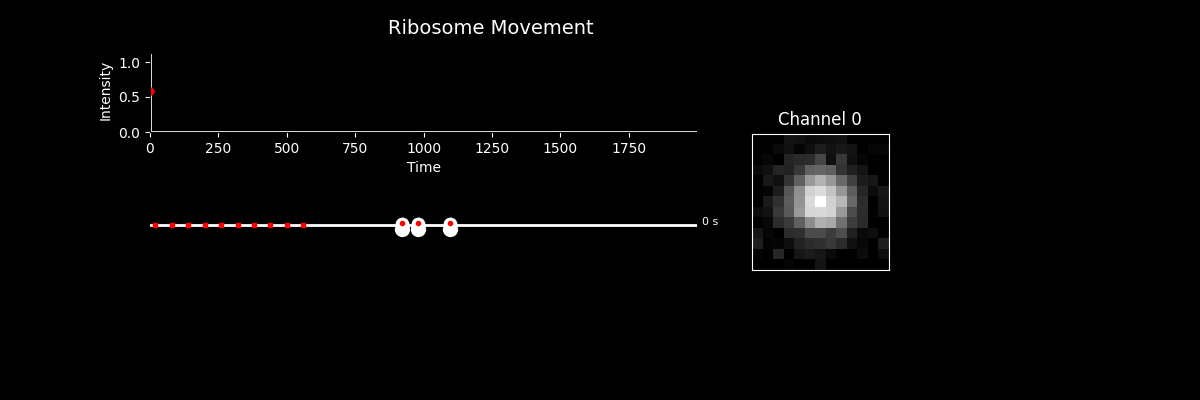

Exception ignored in: <function ResourceTracker.__del__ at 0x1106ff560>
Traceback (most recent call last):
  File "/opt/anaconda3/envs/micro/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/opt/anaconda3/envs/micro/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/opt/anaconda3/envs/micro/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x103bd7560>
Traceback (most recent call last):
  File "/opt/anaconda3/envs/micro/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/opt/anaconda3/envs/micro/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/opt/anaconda3/envs/micro/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function Resour

In [12]:
plot_RibosomeMovement_and_Microscope(ribosome_trajectories[0], intensities_first_signal[0,:], first_probe_position_vector, SecondIntensityVector=None, second_probePositions=None,FrameVelocity=10,fileNameGif='temp.gif')